In [1]:
pip install numpy pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    roc_auc_score, 
    precision_recall_curve, 
    auc
)

In [3]:
# Ensure global presentation style consistency
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

In [4]:
# ==============================================================================
# MACHINE LEARNING FILTERING PIPELINE
# ==============================================================================

def deploy_verification_models(df, feature_cols, target_col='target_label'):
    """
    Splits data, standardizes distance fields, and trains an auditable 
    Decision Tree alongside a K-Nearest Neighbors pattern matcher.
    """
    print("=== STARTING MACHINE LEARNING BASELINE PIPELINE ===")
    
    # Extract feature matrices and labels
    X = df[feature_cols]
    y = df[target_col]
    
    # 1. Stratified Split: Preserves the ~15% hallucination rate across both subsets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=0.20, 
        random_state=42, 
        stratify=y
    )
    print(f"[SPLIT] Training Set Size: {X_train.shape[0]} | Testing Set Size: {X_test.shape[0]}")
    
    # 2. Feature Standardization: Crucial for distance-sensitive models like KNN
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # ==========================================
    # MODEL A: DECISION TREE (Auditable Logic Check)
    # ==========================================
    print("[TRAINING] Fitting Decision Tree Baseline Filter...")
    # Restricting depth to max_depth=4 ensures structural rules remain human-readable
    dt_model = DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42)
    dt_model.fit(X_train_scaled, y_train)
    
    dt_preds = dt_model.predict(X_test_scaled)
    dt_probs = dt_model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate Precision-Recall Metrics for highly imbalanced labels
    dt_precision, dt_recall, _ = precision_recall_curve(y_test, dt_probs, pos_label=1)
    dt_pr_auc = auc(dt_recall, dt_precision)
    
    # ==========================================
    # MODEL B: K-NEAREST NEIGHBORS (Pattern Matcher)
    # ==========================================
    print("[TRAINING] Fitting K-Nearest Neighbors Classifier...")
    knn_model = KNeighborsClassifier(n_neighbors=5, weights='distance')
    knn_model.fit(X_train_scaled, y_train)
    
    knn_preds = knn_model.predict(X_test_scaled)
    knn_probs = knn_model.predict_proba(X_test_scaled)[:, 1]
    
    knn_precision, knn_recall, _ = precision_recall_curve(y_test, knn_probs, pos_label=1)
    knn_pr_auc = auc(knn_recall, knn_precision)
    
    # ==========================================
    # EVALUATION REPORTING ENGINE
    # ==========================================
    print("\n" + "="*50)
    print("MODEL A: DECISION TREE AUDIT TRAIL PROFILE")
    print("="*50)
    print(classification_report(y_test, dt_preds, target_names=['Corrupted (0)', 'Valid (1)'], digits=4))
    print(f"Receiver Operating Characteristic AUC (ROC-AUC): {roc_auc_score(y_test, dt_probs):.4f}")
    print(f"Precision-Recall Area Under Curve (PR-AUC):     {dt_pr_auc:.4f}")
    
    print("\n" + "="*50)
    print("MODEL B: K-NEAREST NEIGHBORS MATRIX PROFILE")
    print("="*50)
    print(classification_report(y_test, knn_preds, target_names=['Corrupted (0)', 'Valid (1)'], digits=4))
    print(f"Receiver Operating Characteristic AUC (ROC-AUC): {roc_auc_score(y_test, knn_probs):.4f}")
    print(f"Precision-Recall Area Under Curve (PR-AUC):     {knn_pr_auc:.4f}\n")
    
    # ==========================================
    # VISUAL CONFUSION MATRIX DASHBOARD
    # ==========================================
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Heatmap 1: Decision Tree
    sns.heatmap(confusion_matrix(y_test, dt_preds), annot=True, fmt='d', cmap='Reds', 
                xticklabels=['Flagged Anomaly', 'Passed Clean'], yticklabels=['True Anomaly', 'True Clean'], ax=axes[0], cbar=False)
    axes[0].set_title("Decision Tree Confusion Matrix")
    axes[0].set_ylabel("True Ground-Truth States")
    axes[0].set_xlabel("Verification Model Action")
    
    # Heatmap 2: KNN
    sns.heatmap(confusion_matrix(y_test, knn_preds), annot=True, fmt='d', cmap='Oranges', 
                xticklabels=['Flagged Anomaly', 'Passed Clean'], yticklabels=['True Anomaly', 'True Clean'], ax=axes[1], cbar=False)
    axes[1].set_title("K-Nearest Neighbors Confusion Matrix")
    axes[1].set_ylabel("True Ground-Truth States")
    axes[1].set_xlabel("Verification Model Action")
    
    plt.tight_layout()
    plt.show()
    
    return dt_model, knn_model, scaler

=== STARTING MACHINE LEARNING BASELINE PIPELINE ===
[SPLIT] Training Set Size: 4000 | Testing Set Size: 1000
[TRAINING] Fitting Decision Tree Baseline Filter...
[TRAINING] Fitting K-Nearest Neighbors Classifier...

MODEL A: DECISION TREE AUDIT TRAIL PROFILE
               precision    recall  f1-score   support

Corrupted (0)     1.0000    1.0000    1.0000       154
    Valid (1)     1.0000    1.0000    1.0000       846

     accuracy                         1.0000      1000
    macro avg     1.0000    1.0000    1.0000      1000
 weighted avg     1.0000    1.0000    1.0000      1000

Receiver Operating Characteristic AUC (ROC-AUC): 1.0000
Precision-Recall Area Under Curve (PR-AUC):     1.0000

MODEL B: K-NEAREST NEIGHBORS MATRIX PROFILE
               precision    recall  f1-score   support

Corrupted (0)     1.0000    1.0000    1.0000       154
    Valid (1)     1.0000    1.0000    1.0000       846

     accuracy                         1.0000      1000
    macro avg     1.0000    1.0

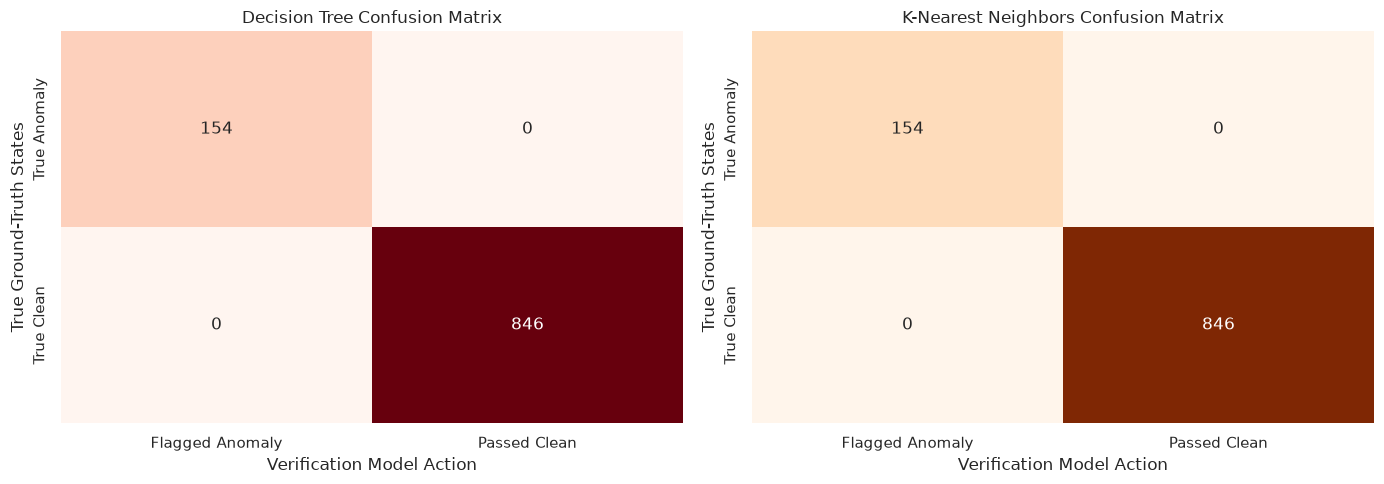

In [6]:
# ==============================================================================
# EXECUTION COHORT RUNNER
# ==============================================================================

if __name__ == "__main__":
    # Generate structured, engineered dataframe mapping back to Part 1 and Part 2
    np.random.seed(42)
    N_samples = 5000
    
    # Simulating continuous post-engineered variables
    simulated_df = pd.DataFrame({
        'log_numerical_delta_rel': np.random.exponential(scale=0.1, size=N_samples),
        'linguistic_confidence': np.random.uniform(0.6, 1.0, size=N_samples),
        'table_proximity_score': np.random.uniform(10.0, 90.0, size=N_samples),
        'text_complexity_score': np.random.uniform(8.0, 16.0, size=N_samples),
        'confidence_complexity_ratio': np.random.uniform(0.05, 0.12, size=N_samples),
        'target_label': np.random.choice([0, 1], size=N_samples, p=[0.15, 0.85]) # 15% Error Imbalance
    })
    
    # Model high-signal discrepancies for the simulation math boundaries
    anomaly_idx = simulated_df[simulated_df['target_label'] == 0].index
    simulated_df.loc[anomaly_idx, 'log_numerical_delta_rel'] += np.random.uniform(1.2, 4.5, size=len(anomaly_idx))
    simulated_df.loc[anomaly_idx, 'linguistic_confidence'] = np.random.uniform(0.90, 1.0, size=len(anomaly_idx))
    simulated_df.loc[anomaly_idx, 'confidence_complexity_ratio'] *= 1.8
    
    # Define model features array
    target_features = [
        'log_numerical_delta_rel', 
        'linguistic_confidence', 
        'table_proximity_score', 
        'text_complexity_score', 
        'confidence_complexity_ratio'
    ]
    
    # Execute Model Pipelines
    dt_clf, knn_clf, standard_scaler = deploy_verification_models(simulated_df, target_features)